In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("youtube_analytics.csv")

In [3]:
df

,video_id,day,views,redViews,comments,likes,dislikes,videosAddedToPlaylists,videosRemovedFromPlaylists,shares,...,annotationClicks,annotationCloses,cardClickRate,cardTeaserClickRate,cardImpressions,cardTeaserImpressions,cardClicks,cardTeaserClicks,subscribersGained,subscribersLost
0,YuQaT52VEwo,2019-09-06,8.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,YuQaT52VEwo,2019-09-07,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SfTEVOQP-Hk,2019-09-07,6.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,YuQaT52VEwo,2019-09-08,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SfTEVOQP-Hk,2019-09-08,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234884,jCBMPRa88_4,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234885,bN7jBc95XDo,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234886,ZwtHeB7L6lA,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
234887,5DM_c9zMn0U,2024-11-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.columns

Index(['video_id', 'day', 'views', 'redViews', 'comments', 'likes', 'dislikes',
       'videosAddedToPlaylists', 'videosRemovedFromPlaylists', 'shares',
       'estimatedMinutesWatched', 'estimatedRedMinutesWatched',
       'averageViewDuration', 'averageViewPercentage',
       'annotationClickThroughRate', 'annotationCloseRate',
       'annotationImpressions', 'annotationClickableImpressions',
       'annotationClosableImpressions', 'annotationClicks', 'annotationCloses',
       'cardClickRate', 'cardTeaserClickRate', 'cardImpressions',
       'cardTeaserImpressions', 'cardClicks', 'cardTeaserClicks',
       'subscribersGained', 'subscribersLost'],
      dtype='object')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

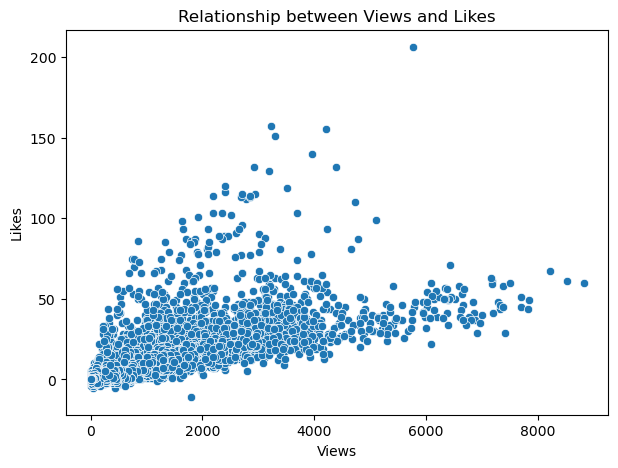

In [16]:
# Relationship between views and likes
plt.figure(figsize=(7, 5))
sns.scatterplot(x='views', y='likes', data=df)
plt.title('Relationship between Views and Likes')
plt.xlabel('Views')
plt.ylabel('Likes')
plt.show()

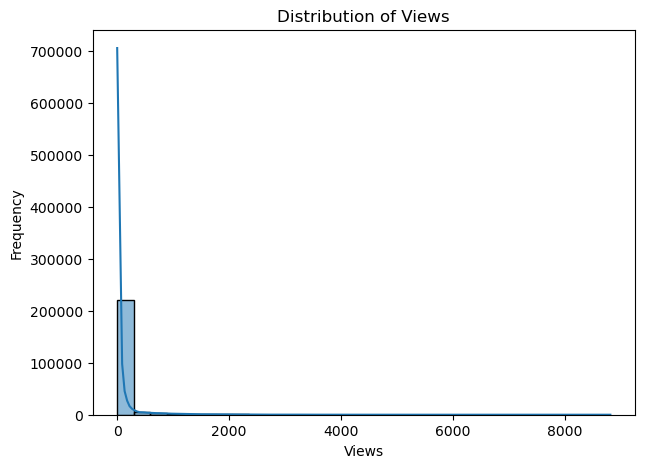

In [15]:
# Explore individual columns
# Example: Distribution of views
plt.figure(figsize=(7, 5))
sns.histplot(df['views'], bins=30, kde=True)
plt.title('Distribution of Views')
plt.xlabel('Views')
plt.ylabel('Frequency')
plt.show()

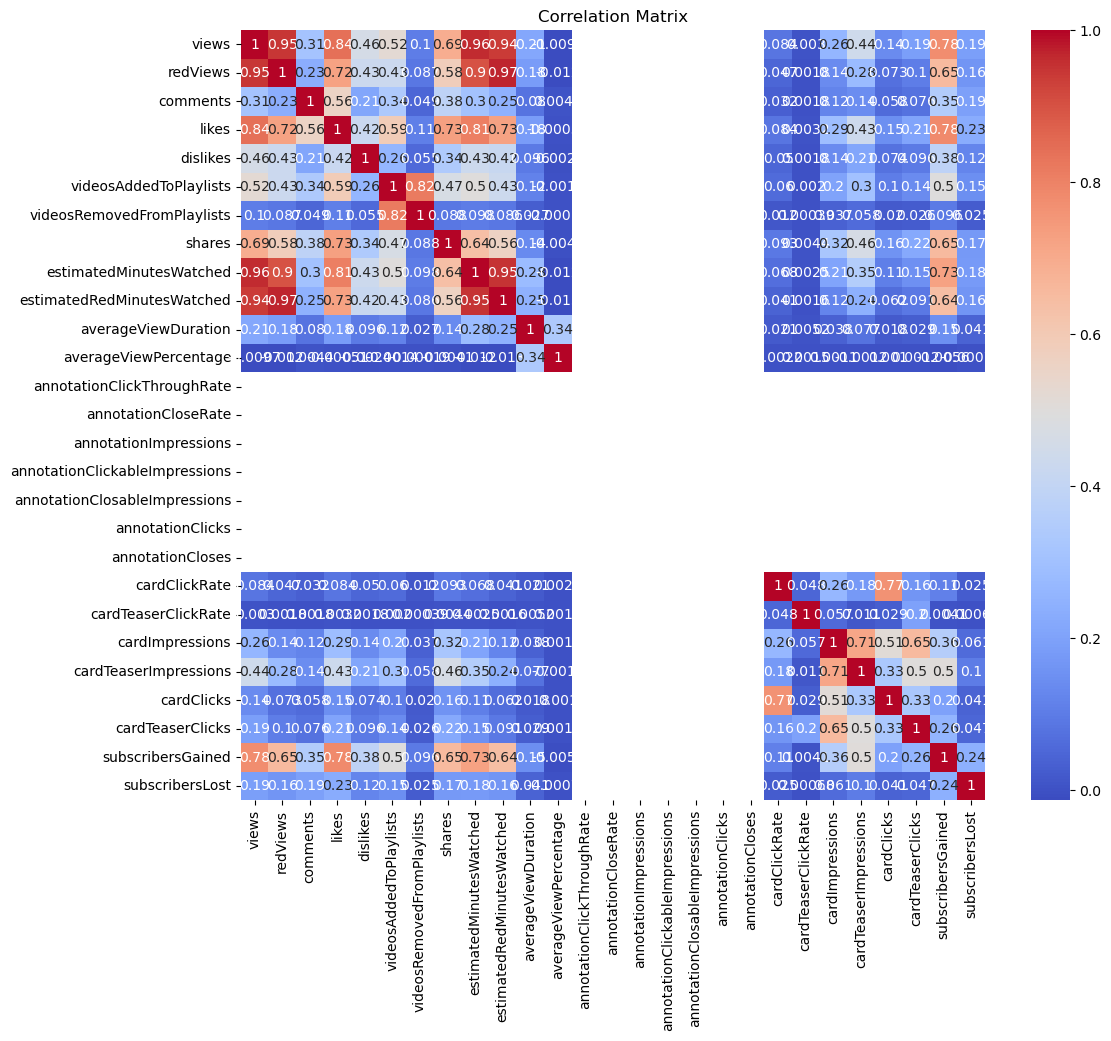

In [8]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')  # Add numeric_only=True
plt.title('Correlation Matrix')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numerical_features = df.select_dtypes(include=['number']).columns
X = df[numerical_features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(8)  # You can specify n_components if desired
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)

# Cumulative explained variance
cumulative_variance = explained_variance_ratio.cumsum()
print("\nCumulative Explained Variance:", cumulative_variance)






Explained Variance Ratio: [0.35188673 0.12492986 0.07888446 0.06596652 0.06291701 0.05514314
 0.05060125 0.04259447]

Cumulative Explained Variance: [0.35188673 0.47681659 0.55570105 0.62166758 0.68458458 0.73972772
 0.79032898 0.83292344]


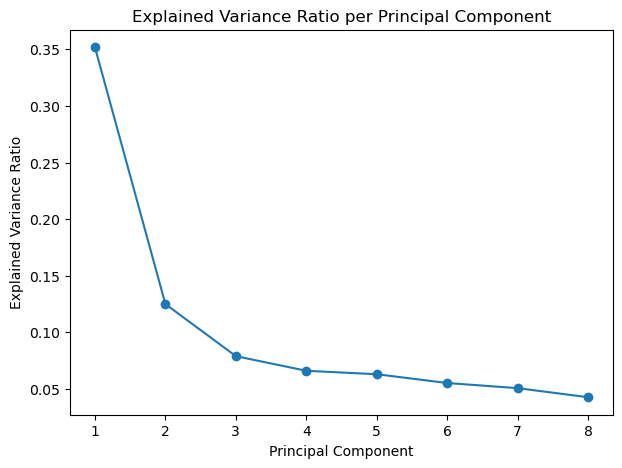

In [13]:
# Plot explained variance
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

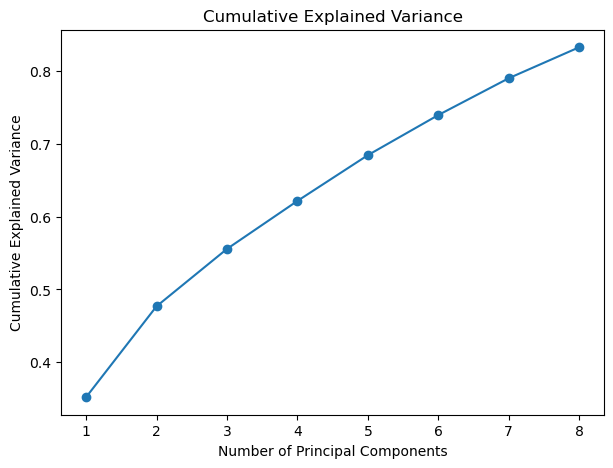

In [18]:
# Plot cumulative explained variance
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()


In [12]:
# Create a DataFrame with principal components
principal_df = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# Print the reduced dimensionality table
print(principal_df)

             PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0      -0.611487  0.062604  0.013356  0.068390  0.063179 -0.073090 -0.013394   
1      -0.721529  0.116718  0.162359 -0.606276 -0.218094  0.042361  0.004030   
2      -0.547035 -0.001253  0.055857  1.242421  0.499959 -0.138192 -0.055973   
3      -0.526835 -0.059518 -0.213861  2.356022  0.949734 -0.262155 -0.093406   
4      -0.521950 -0.065790 -0.226365  2.503536  1.009318 -0.280393 -0.098510   
...          ...       ...       ...       ...       ...       ...       ...   
234884 -0.800963  0.155456  0.137263 -1.119732 -0.411563  0.085216  0.020565   
234885 -0.800963  0.155456  0.137263 -1.119732 -0.411563  0.085216  0.020565   
234886 -0.800963  0.155456  0.137263 -1.119732 -0.411563  0.085216  0.020565   
234887 -0.800963  0.155456  0.137263 -1.119732 -0.411563  0.085216  0.020565   
234888 -0.800963  0.155456  0.137263 -1.119732 -0.411563  0.085216  0.020565   

             PC8  
0      -0.042819  
1

<BarContainer object of 234889 artists>

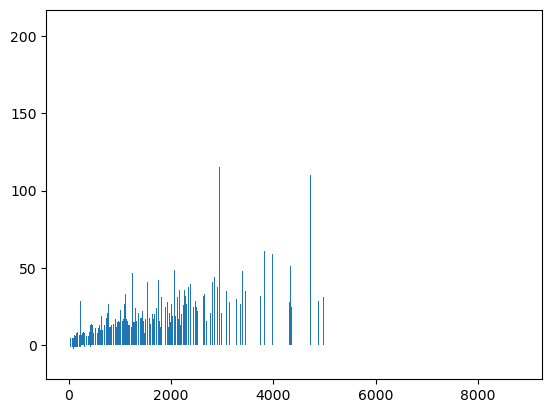

In [20]:
plt.bar(df['views'],df['likes'])

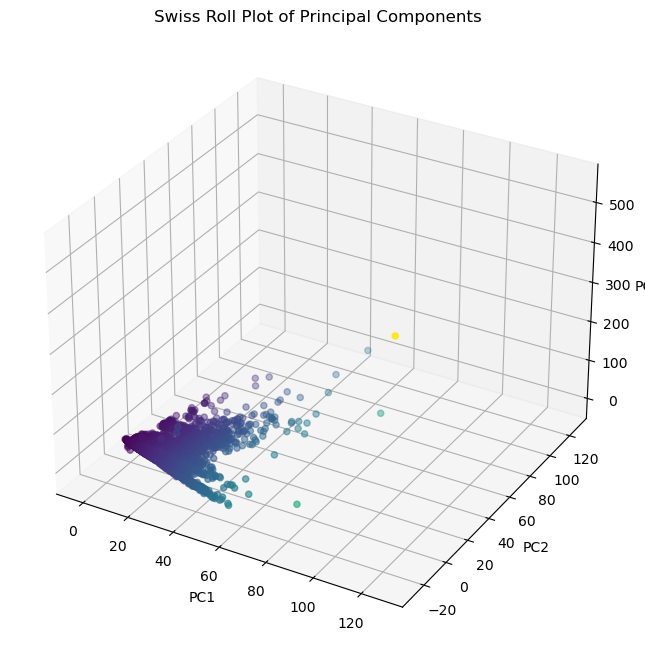

In [21]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=X_pca[:, 0], cmap='viridis')  # Assuming 3 components

# Customize the plot
ax.set_title('Swiss Roll Plot of Principal Components')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

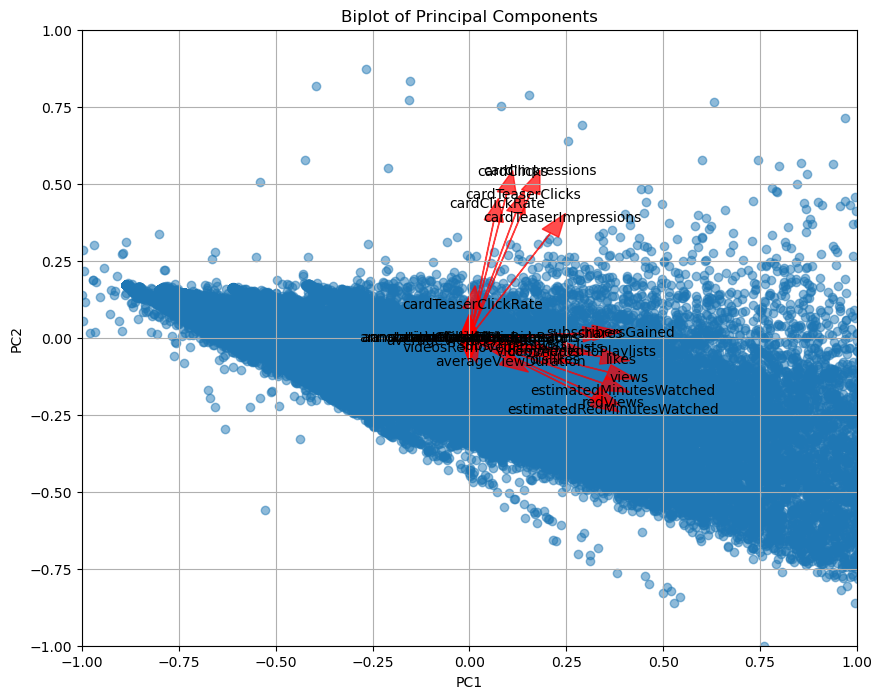

In [22]:
plt.figure(figsize=(10, 8))

# Plot the data points (observations)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)  # Assuming 2 components

# Plot the feature vectors (loadings)
feature_vectors = pca.components_.T  # Get the feature vectors (loadings)
for i, feature in enumerate(numerical_features):
    plt.arrow(0, 0, feature_vectors[i, 0], feature_vectors[i, 1], color='r', alpha=0.7, head_width=0.05)
    plt.text(feature_vectors[i, 0] * 1.15, feature_vectors[i, 1] * 1.15, feature, color='k', ha='center', va='center')

# Customize the plot
plt.title('Biplot of Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim([-1, 1])  # Adjust limits as needed
plt.ylim([-1, 1])
plt.grid(True)

plt.show()

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.xticks(range(1, len(eigenvalues) + 1))  # Set x-axis ticks to component numbers
plt.grid(True)

plt.show()

NameError: name 'eigenvalues' is not defined

<Figure size 1000x600 with 0 Axes>